# Modélisation et tracking MLflow

## Préparation des données

In [1]:
# chargement es données
import pandas as pd
import numpy as np

app_train = pd.read_csv("../donnees/traitees/dataset_final_train.csv")
print("Dimensions :", app_train.shape)

Dimensions : (307503, 841)


## Séparation features/cible et split train/validation

In [2]:
from sklearn.model_selection import train_test_split

# Séparation features (X) et cible (y)
X = app_train.drop(columns=["TARGET", "SK_ID_CURR"])
y = app_train["TARGET"]

# Split train/validation (80/20), stratifié pour garder le même déséquilibre de classes des deux côtés
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y )

print("X_train :", X_train.shape)
print("X_valid :", X_valid.shape)
print("Proportion TARGET=1 dans y_train :", y_train.mean().round(4))
print("Proportion TARGET=1 dans y_valid :", y_valid.mean().round(4))

X_train : (246002, 839)
X_valid : (61501, 839)
Proportion TARGET=1 dans y_train : 0.0807
Proportion TARGET=1 dans y_valid : 0.0807


## Modèles   
Corrections app_train

In [6]:
# Identifier les colonnes non-numériques dans X_train
colonnes_problematiques = X_train.select_dtypes(exclude=["number"]).columns.tolist()
print("Colonnes problématiques :", colonnes_problematiques)
print("Nombre de colonnes concernées :", len(colonnes_problematiques))

Colonnes problématiques : ['BUREAU_CREDIT_ACTIVE_ACTIVE_MIN', 'BUREAU_CREDIT_ACTIVE_ACTIVE_MAX', 'BUREAU_CREDIT_ACTIVE_BAD DEBT_MIN', 'BUREAU_CREDIT_ACTIVE_BAD DEBT_MAX', 'BUREAU_CREDIT_ACTIVE_CLOSED_MIN', 'BUREAU_CREDIT_ACTIVE_CLOSED_MAX', 'BUREAU_CREDIT_ACTIVE_SOLD_MIN', 'BUREAU_CREDIT_ACTIVE_SOLD_MAX', 'BUREAU_CREDIT_ACTIVE_NAN_MIN', 'BUREAU_CREDIT_ACTIVE_NAN_MAX', 'BUREAU_CREDIT_CURRENCY_CURRENCY 1_MIN', 'BUREAU_CREDIT_CURRENCY_CURRENCY 1_MAX', 'BUREAU_CREDIT_CURRENCY_CURRENCY 2_MIN', 'BUREAU_CREDIT_CURRENCY_CURRENCY 2_MAX', 'BUREAU_CREDIT_CURRENCY_CURRENCY 3_MIN', 'BUREAU_CREDIT_CURRENCY_CURRENCY 3_MAX', 'BUREAU_CREDIT_CURRENCY_CURRENCY 4_MIN', 'BUREAU_CREDIT_CURRENCY_CURRENCY 4_MAX', 'BUREAU_CREDIT_CURRENCY_NAN_MIN', 'BUREAU_CREDIT_CURRENCY_NAN_MAX', 'BUREAU_CREDIT_TYPE_ANOTHER TYPE OF LOAN_MIN', 'BUREAU_CREDIT_TYPE_ANOTHER TYPE OF LOAN_MAX', 'BUREAU_CREDIT_TYPE_CAR LOAN_MIN', 'BUREAU_CREDIT_TYPE_CAR LOAN_MAX', 'BUREAU_CREDIT_TYPE_CASH LOAN (NON-EARMARKED)_MIN', 'BUREAU_CREDIT_TY

In [7]:
# Conversion des colonnes problématiques en numérique
for col in colonnes_problematiques:
    X_train[col] = X_train[col].replace({"True": 1, "False": 0, True: 1, False: 0}).astype(float)
    X_valid[col] = X_valid[col].replace({"True": 1, "False": 0, True: 1, False: 0}).astype(float)

# Vérification
colonnes_restantes = X_train.select_dtypes(exclude=["number"]).columns.tolist()
print("Colonnes encore problématiques :", colonnes_restantes)

Colonnes encore problématiques : []


In [9]:
import numpy as np

# Identifier les colonnes contenant des valeurs infinies
colonnes_avec_inf = X_train.columns[np.isinf(X_train).any()].tolist()
print("Colonnes avec des valeurs infinies :", colonnes_avec_inf)
print("Nombre de colonnes concernées :", len(colonnes_avec_inf))

Colonnes avec des valeurs infinies : ['PREV_APP_CREDIT_PERC_MAX', 'PREV_APP_CREDIT_PERC_MEAN', 'REFUSED_APP_CREDIT_PERC_MAX', 'REFUSED_APP_CREDIT_PERC_MEAN', 'INSTAL_PAYMENT_PERC_MAX', 'INSTAL_PAYMENT_PERC_MEAN', 'INSTAL_PAYMENT_PERC_SUM']
Nombre de colonnes concernées : 7


In [10]:
import numpy as np

# Remplacer les valeurs infinies par NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_valid = X_valid.replace([np.inf, -np.inf], np.nan)

# Réimputer ces nouveaux NaN par la médiane de X_train
colonnes_avec_inf = ["PREV_APP_CREDIT_PERC_MAX", "PREV_APP_CREDIT_PERC_MEAN", 
                       "REFUSED_APP_CREDIT_PERC_MAX", "REFUSED_APP_CREDIT_PERC_MEAN",
                       "INSTAL_PAYMENT_PERC_MAX", "INSTAL_PAYMENT_PERC_MEAN", 
                       "INSTAL_PAYMENT_PERC_SUM"]

for col in colonnes_avec_inf:
    mediane = X_train[col].median()
    X_train[col] = X_train[col].fillna(mediane)
    X_valid[col] = X_valid[col].fillna(mediane)

print("Valeurs infinies restantes :", np.isinf(X_train).any().sum())
print("Valeurs manquantes restantes :", X_train.isnull().sum().sum())

Valeurs infinies restantes : 0
Valeurs manquantes restantes : 0


In [13]:
# Même correction sur app_train complet, pour cohérence de sauvegarde
colonnes_a_verifier_train = app_train.select_dtypes(exclude=["number"]).columns.tolist()
print("Colonnes non-numériques dans app_train :", len(colonnes_a_verifier_train))

for col in colonnes_a_verifier_train:
    app_train[col] = app_train[col].replace({"True": 1, "False": 0, True: 1, False: 0}).astype(float)

app_train = app_train.replace([np.inf, -np.inf], np.nan)

for col in colonnes_avec_inf:
    if col in app_train.columns:
        mediane = app_train[col].median()
        app_train[col] = app_train[col].fillna(mediane)

print("Valeurs manquantes restantes dans app_train :", app_train.isnull().sum().sum())
print("Valeurs infinies restantes dans app_train :", np.isinf(app_train.select_dtypes(include='number')).sum().sum())

# Sauvegarde
app_train.to_csv("../donnees/traitees/dataset_final_train.csv", index=False)
print("app_train corrigé et sauvegardé.")

Colonnes non-numériques dans app_train : 52
Valeurs manquantes restantes dans app_train : 0
Valeurs infinies restantes dans app_train : 0
app_train corrigé et sauvegardé.


Corrections app_test

In [12]:
app_test = pd.read_csv("../donnees/traitees/dataset_final_test.csv")
print("Dimensions app_test :", app_test.shape)

# Identification et correction des colonnes non-numériques dans app_test
colonnes_a_verifier = app_test.select_dtypes(exclude=["number"]).columns.tolist()
print("Colonnes non-numériques dans app_test :", len(colonnes_a_verifier))

for col in colonnes_a_verifier:
    app_test[col] = app_test[col].replace({"True": 1, "False": 0, True: 1, False: 0}).astype(float)

# Correction des valeurs infinies
app_test = app_test.replace([np.inf, -np.inf], np.nan)

for col in colonnes_avec_inf:
    if col in app_test.columns:
        mediane = X_train[col].median()  # on réutilise la médiane calculée sur X_train, jamais sur test
        app_test[col] = app_test[col].fillna(mediane)

print("Valeurs manquantes restantes dans app_test :", app_test.isnull().sum().sum())
print("Valeurs infinies restantes dans app_test :", np.isinf(app_test.select_dtypes(include='number')).sum().sum())

Dimensions app_test : (48744, 840)
Colonnes non-numériques dans app_test : 52
Valeurs manquantes restantes dans app_test : 0
Valeurs infinies restantes dans app_test : 0


In [14]:
app_test.to_csv("../donnees/traitees/dataset_final_test.csv", index=False)
print("app_test corrigé et sauvegardé.")

app_test corrigé et sauvegardé.


### Modélisation

#### Fonction de métriques d'évaluation
Une fonction unique calculant toutes les métriques nécessaires : AUC-ROC, recall (classe minoritaire), F1-score, et le score/coût métier personnalisé (FN pénalisé 10x plus que FP).

In [21]:
from sklearn.metrics import roc_auc_score, recall_score, f1_score, confusion_matrix

def calculer_metriques(y_vrai, y_pred, y_pred_proba, cout_fn=10, cout_fp=1):
    auc = roc_auc_score(y_vrai, y_pred_proba)
    recall = recall_score(y_vrai, y_pred)
    f1 = f1_score(y_vrai, y_pred)
    
    tn, fp, fn, tp = confusion_matrix(y_vrai, y_pred).ravel()
    cout_metier = (fn * cout_fn + fp * cout_fp) / len(y_vrai)
    
    return {
        "auc": auc,
        "recall": recall,
        "f1": f1,
        "cout_metier": cout_metier,
        "fn": fn,
        "fp": fp }

#### Validation croisée (StratifiedKFold)   
5 folds, pour une évaluation robuste de chaque modèle.

In [22]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#### Régression Logistique

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer

# Transformer notre fonction coût métier en "scorer" utilisable par cross_validate
def cout_metier_scorer(y_vrai, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_vrai, y_pred).ravel()
    return (fn * 10 + fp * 1) / len(y_vrai)

scorer_cout_metier = make_scorer(cout_metier_scorer, greater_is_better=False)

with mlflow.start_run(run_name="regression_logistique_cv"):
    C = 0.0001
    
    modele = LogisticRegression(C=C, class_weight="balanced", random_state=42, max_iter=1000)
    
    resultats_cv = cross_validate(
        modele, X_train, y_train, cv=cv,
        scoring={"auc": "roc_auc", "recall": "recall", "f1": "f1", "cout_metier": scorer_cout_metier},
        return_train_score=False
    )
    
    auc = resultats_cv["test_auc"].mean()
    recall = resultats_cv["test_recall"].mean()
    f1 = resultats_cv["test_f1"].mean()
    cout_metier = -resultats_cv["test_cout_metier"].mean()  # on annule le signe négatif imposé par greater_is_better=False
    
    mlflow.log_param("C", C)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metric("auc", auc)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("cout_metier", cout_metier)
    
    print(f"AUC : {auc:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1 : {f1:.4f}")
    print(f"Coût métier : {cout_metier:.4f}")

c:\Users\yavas\credit_scoring\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\yavas\credit_scoring\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproces

AUC : 0.6789
Recall : 0.6085
F1 : 0.2219
Coût métier : 0.6290


#### Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

with mlflow.start_run(run_name="random_forest"):
    n_estimators = 100
    
    modele = RandomForestClassifier(n_estimators=n_estimators, class_weight="balanced", random_state=42, n_jobs=-1)
    
    resultats_cv = cross_validate(
        modele, X_train, y_train, cv=cv,
        scoring={"auc": "roc_auc", "recall": "recall", "f1": "f1", "cout_metier": scorer_cout_metier},
        return_train_score=False)
    
    auc = resultats_cv["test_auc"].mean()
    recall = resultats_cv["test_recall"].mean()
    f1 = resultats_cv["test_f1"].mean()
    cout_metier = -resultats_cv["test_cout_metier"].mean()
    
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metric("auc", auc)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("cout_metier", cout_metier)
    
    print(f"AUC : {auc:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1 : {f1:.4f}")
    print(f"Coût métier : {cout_metier:.4f}")

AUC : 0.7443
Recall : 0.0308
F1 : 0.0573
Coût métier : 0.7859


#### LightGBM

In [27]:
# nettoyer les noms des colonnes pour acceptation lighgbm
import re

def nettoyer_noms_colonnes(df):
    df = df.copy()
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df.columns]
    return df

X_train = nettoyer_noms_colonnes(X_train)
X_valid = nettoyer_noms_colonnes(X_valid)

print("Exemple de noms de colonnes après nettoyage :")
print(X_train.columns[:5].tolist())

Exemple de noms de colonnes après nettoyage :
['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']


In [28]:
import lightgbm as lgb

with mlflow.start_run(run_name="lightgbm"):
    n_estimators = 100
    learning_rate = 0.1
    
    modele = lgb.LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    resultats_cv = cross_validate(
        modele, X_train, y_train, cv=cv,
        scoring={"auc": "roc_auc", "recall": "recall", "f1": "f1", "cout_metier": scorer_cout_metier},
        return_train_score=False
    )
    
    auc = resultats_cv["test_auc"].mean()
    recall = resultats_cv["test_recall"].mean()
    f1 = resultats_cv["test_f1"].mean()
    cout_metier = -resultats_cv["test_cout_metier"].mean()
    
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metric("auc", auc)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("cout_metier", cout_metier)
    
    print(f"AUC : {auc:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1 : {f1:.4f}")
    print(f"Coût métier : {cout_metier:.4f}")

AUC : 0.7837
Recall : 0.6890
F1 : 0.2944
Coût métier : 0.4926


#### XGBoost

In [29]:
from xgboost import XGBClassifier

with mlflow.start_run(run_name="xgboost"):
    n_estimators = 100
    learning_rate = 0.1
    
    # XGBoost n'a pas class_weight, on utilise scale_pos_weight à la place
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    modele = XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    )
    
    resultats_cv = cross_validate(
        modele, X_train, y_train, cv=cv,
        scoring={"auc": "roc_auc", "recall": "recall", "f1": "f1", "cout_metier": scorer_cout_metier},
        return_train_score=False
    )
    
    auc = resultats_cv["test_auc"].mean()
    recall = resultats_cv["test_recall"].mean()
    f1 = resultats_cv["test_f1"].mean()
    cout_metier = -resultats_cv["test_cout_metier"].mean()
    
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("scale_pos_weight", scale_pos_weight)
    mlflow.log_metric("auc", auc)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("cout_metier", cout_metier)
    
    print(f"AUC : {auc:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1 : {f1:.4f}")
    print(f"Coût métier : {cout_metier:.4f}")

AUC : 0.7799
Recall : 0.6619
F1 : 0.2973
Coût métier : 0.4983


#### MLP

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

with mlflow.start_run(run_name="mlp"):
    hidden_layer_sizes = (100,)
    modele = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, random_state=42, max_iter=300))
        # activation="relu" (valeur par défaut non modifiée) : standard, évite le vanishing gradient, calcul rapide adapté aux grands dataset
    
    resultats_cv = cross_validate(
        modele, X_train, y_train, cv=cv,
        scoring={"auc": "roc_auc", "recall": "recall", "f1": "f1", "cout_metier": scorer_cout_metier},
        return_train_score=False
    )
    
    auc = resultats_cv["test_auc"].mean()
    recall = resultats_cv["test_recall"].mean()
    f1 = resultats_cv["test_f1"].mean()
    cout_metier = -resultats_cv["test_cout_metier"].mean()
    
    mlflow.log_param("hidden_layer_sizes", str(hidden_layer_sizes))
    mlflow.log_metric("auc", auc)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("cout_metier", cout_metier)
    
    print(f"AUC : {auc:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1 : {f1:.4f}")
    print(f"Coût métier : {cout_metier:.4f}")

c:\Users\yavas\credit_scoring\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
c:\Users\yavas\credit_scoring\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


AUC : 0.6543
Recall : 0.1777
F1 : 0.1847
Coût métier : 0.7235


Lightgbm a de meilleurs scores donc on choisit ce modèle.

In [32]:
# Nettoyage des noms de colonnes sur app_train et app_test complets 
app_train = nettoyer_noms_colonnes(app_train)
app_test = nettoyer_noms_colonnes(app_test)

# Sauvegarde des versions définitives
app_train.to_csv("../donnees/traitees/dataset_final_train.csv", index=False)
app_test.to_csv("../donnees/traitees/dataset_final_test.csv", index=False)

print("Datasets finaux.")
print("app_train :", app_train.shape)
print("app_test :", app_test.shape)

Datasets finaux.
app_train : (307503, 841)
app_test : (48744, 840)


### Feature Importance Globale
Quelles variables contribuent le plus aux décisions du modèle, en moyenne sur tous les clients.

c:\Users\yavas\credit_scoring\venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


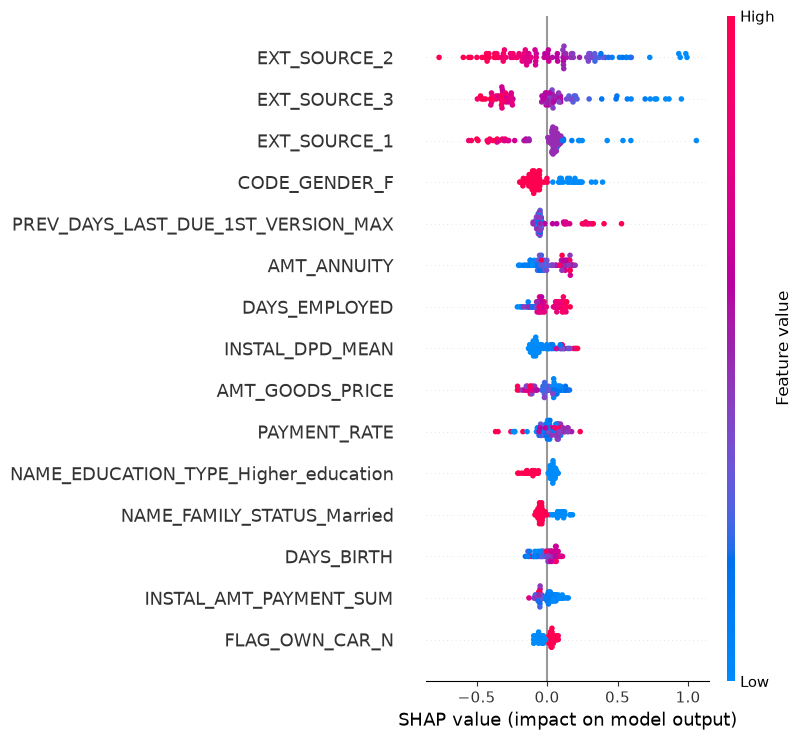

In [52]:
import shap
explainer= shap.TreeExplainer(modele_final)
shap_values=explainer.shap_values(X_valid.iloc[:100])        #calculer les valeurs shap sur un echantillon
shap.summary_plot(shap_values,X_valid.iloc[:100],max_display=15)     #top 15 features

Ex Ext_source_2: Plus le score est faible (en bleu), plus le risque de défaut calculé par le modèle est fort (poussé vers la droite/refus du pret)

### Feature Importance Locale   
SHAP décompose, pour un client précis, la contribution de chaque variable à sa probabilité de défaut

c:\Users\yavas\credit_scoring\venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


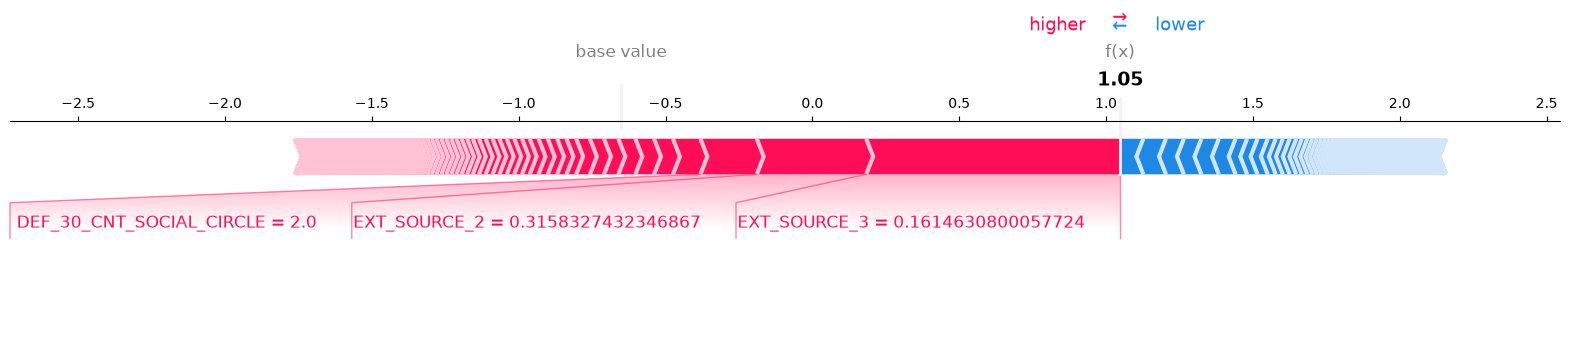

In [ ]:
import shap

explainer = shap.TreeExplainer(modele_final)
shap_values = explainer.shap_values(X_valid.iloc[:100]) 

# Exemple d'un profil à fort risque (mauvais payeur)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[20],X_valid.iloc[20],matplotlib=True)

Cohérence avec feature importance globale car on remarque que les faibles valeurs de ext_source_2,ext_source_3...font basculer la prédicition globale du coté du risque.

## Optimisation   
### GridSearchCV : Recherche des meilleurs hyperparamètres en utilisant le coût métier comme critère de sélection.

In [ ]:
from sklearn.model_selection import GridSearchCV

parametres_grille = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [31, 50]
}

modele_base = lgb.LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=1, verbose=-1)

grid_search = GridSearchCV(
    modele_base,
    param_grid=parametres_grille,
    scoring=scorer_cout_metier,
    cv=cv,
    n_jobs=2,  
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur coût métier (CV) :", -grid_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Meilleurs paramètres : {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 50}
Meilleur coût métier (CV) : 0.49078056455987823


In [36]:
with mlflow.start_run(run_name="lightgbm_gridsearch_optimise"):
    meilleurs_params = grid_search.best_params_
    
    modele_optimal = lgb.LGBMClassifier(
        **meilleurs_params,
        class_weight="balanced",
        random_state=42,
        n_jobs=1,
        verbose=-1
    )
    
    resultats_cv = cross_validate(
        modele_optimal, X_train, y_train, cv=cv,
        scoring={"auc": "roc_auc", "recall": "recall", "f1": "f1", "cout_metier": scorer_cout_metier},
        return_train_score=False
    )
    
    auc = resultats_cv["test_auc"].mean()
    recall = resultats_cv["test_recall"].mean()
    f1 = resultats_cv["test_f1"].mean()
    cout_metier = -resultats_cv["test_cout_metier"].mean()
    
    for param, valeur in meilleurs_params.items():
        mlflow.log_param(param, valeur)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metric("auc", auc)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("cout_metier", cout_metier)
    
    print(f"AUC : {auc:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1 : {f1:.4f}")
    print(f"Coût métier : {cout_metier:.4f}")

AUC : 0.7850
Recall : 0.6697
F1 : 0.3013
Coût métier : 0.4908


### Seuil de décision : Test de seuils de 0.1 à 0.9 pour minimiser le coût métier.

Meilleur seuil : 0.50
Coût métier associé : 0.4951


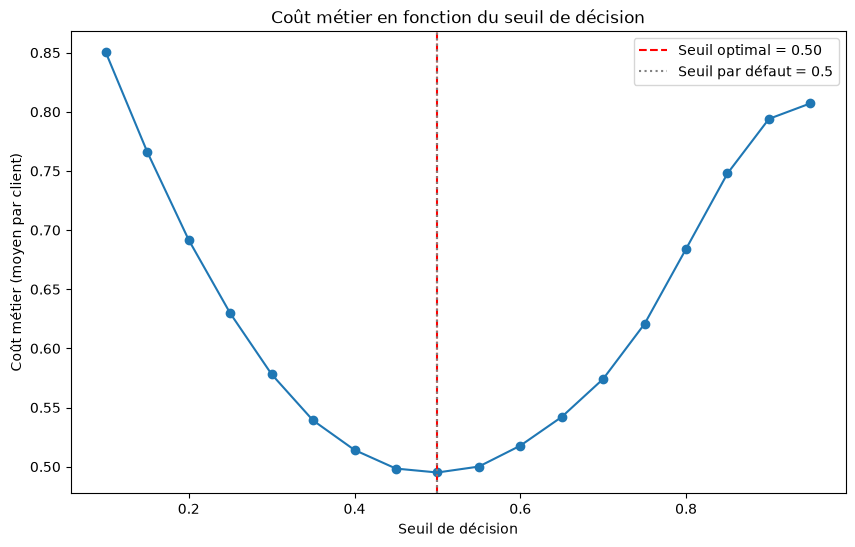

In [ ]:
import matplotlib.pyplot as plt

# Entraînement du modèle optimal sur X_train, prédiction sur X_valid
modele_final = lgb.LGBMClassifier(**grid_search.best_params_, class_weight="balanced", random_state=42, n_jobs=1, verbose=-1)
modele_final.fit(X_train, y_train)
y_proba_valid = modele_final.predict_proba(X_valid)[:, 1]

# Test de différents seuils
seuils = np.arange(0.1, 1.0, 0.05)
couts = []

for seuil in seuils:
    y_pred_seuil = (y_proba_valid >= seuil).astype(int)           #classe un client en mauvais payeur dès qu'il dépasse le sueil
    tn, fp, fn, tp = confusion_matrix(y_valid, y_pred_seuil).ravel()   #extrait la matrice de confusion
    cout = (fn * 10 + fp * 1) / len(y_valid)                           #calcule cout moyen métier
    couts.append(cout)

# Trouver le meilleur seuil
meilleur_seuil = seuils[np.argmin(couts)]
meilleur_cout = min(couts)

print(f"Meilleur seuil : {meilleur_seuil:.2f}")
print(f"Coût métier associé : {meilleur_cout:.4f}")

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(seuils, couts, marker="o")
plt.axvline(x=meilleur_seuil, color="red", linestyle="--", label=f"Seuil optimal = {meilleur_seuil:.2f}")
plt.axvline(x=0.5, color="gray", linestyle=":", label="Seuil par défaut = 0.5")
plt.xlabel("Seuil de décision")
plt.ylabel("Coût métier (moyen par client)")
plt.title("Coût métier en fonction du seuil de décision")
plt.legend()
plt.show()

In [ ]:
with mlflow.start_run(run_name="lightgbm_final_seuil_optimise"):
    for param, valeur in grid_search.best_params_.items():
        mlflow.log_param(param, valeur)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("seuil_optimal", meilleur_seuil)
    
    y_pred_final = (y_proba_valid >= meilleur_seuil).astype(int)
    auc_final = roc_auc_score(y_valid, y_proba_valid)
    recall_final = recall_score(y_valid, y_pred_final)
    f1_final = f1_score(y_valid, y_pred_final)
    
    mlflow.log_metric("auc", auc_final)
    mlflow.log_metric("recall", recall_final)
    mlflow.log_metric("f1", f1_final)
    mlflow.log_metric("cout_metier", meilleur_cout)
    
    # Log du modèle lui-même
    mlflow.lightgbm.log_model(modele_final, name="modele_lightgbm_final")
    
    print(f"Modèle final enregistré avec seuil optimal = {meilleur_seuil}")

Modèle final enregistré avec seuil optimal = 0.5000000000000001


### Vérification de l'overfitting sur le modèle final
Comparaison du score sur les données d'entraînement vs. validation, pour détecter un éventuel surapprentissage ( AUC > 0.82 = signal d'alerte).

In [42]:
# Score sur les données d'entraînement
y_proba_train = modele_final.predict_proba(X_train)[:, 1]
auc_train = roc_auc_score(y_train, y_proba_train)

# Score sur les données de validation
auc_valid = roc_auc_score(y_valid, y_proba_valid)

print(f"AUC sur X_train : {auc_train:.4f}")
print(f"AUC sur X_valid : {auc_valid:.4f}")
print(f"Écart train/valid : {auc_train - auc_valid:.4f}")

if auc_valid > 0.82:
    print(f"AUC valid ({auc_valid:.4f}) > 0.82 : score suspect")
else:
    print(f"AUC valid ({auc_valid:.4f}) < 0.82 : score cohérent")

AUC sur X_train : 0.8596
AUC sur X_valid : 0.7832
Écart train/valid : 0.0765
AUC valid (0.7832) < 0.82 : score cohérent


### Lien entre pérformance technique et métier

L'évaluation de credit_scoring dépasse les métriques techniques comme par ex l'AUC(0.783) : un faux positif (pret accordé à un défaillant) coute fianancièrement plus cher à la banque qu'un faux négatif(refus d'un bon client). L'étape optimisation a donc ajusté le seuil de décision pour maximiser le rappel(0.669) permettant de détecter 67% des mauvais payeurs tout en minimisant la fonction de cout métier au niveau le plus bas(0.495). Le modèle priviligie ainsi la rentabilité et la maitrise du risque, le tout couplé à l'explicabilité SHAP pour justifier chaque refus de manière transparente.

## Documentation des runs (tags et descriptions).

In [43]:
client = mlflow.tracking.MlflowClient()
runs = mlflow.search_runs(experiment_ids=["1"])

descriptions = {
    "regression_logistique_cv": "Régression logistique(baseline) avec class_weight=balanced et validation croisée",
    "random_forest": "Random Forest avec class_weight=balanced,cv,recall très faible malgré la pondération",
    "lightgbm": "LightGBM baseline,cv,meilleur modèle initial",
    "xgboost": "XGBoost avec scale_pos_weight,cv,performances proches de LightGBM",
    "mlp": "Réseau de neurones (MLP),cv, performances décevantes",
    "lightgbm_gridsearch_optimise": "LightGBM avec hyperparamètres optimisés via GridSearchCV",
    "lightgbm_final_seuil_optimise": "Modèle final retenu : LightGBM optimisé + seuil de décision ajusté"
}

types_modeles = {
    "regression_logistique_cv": "lineaire",
    "random_forest": "foret",
    "lightgbm": "boosting",
    "xgboost": "boosting",
    "mlp": "reseau_neurones",
    "lightgbm_gridsearch_optimise": "boosting",
    "lightgbm_final_seuil_optimise": "boosting"
}

for _, run in runs.iterrows():
    nom = run["tags.mlflow.runName"]
    if nom in descriptions:
        client.set_tag(run["run_id"], "mlflow.note.content", descriptions[nom])
        client.set_tag(run["run_id"], "type_modele", types_modeles.get(nom, "non_specifie"))

## Enregistrement dans le Model Registry / MLFlow

In [53]:
# Récupérer le run_id du modèle final
runs = mlflow.search_runs(experiment_ids=["1"])
run_id_final = runs[runs["tags.mlflow.runName"] == "lightgbm_final_seuil_optimise"]["run_id"].values[0]

# Enregistrement dans le Model Registry
resultat = mlflow.register_model(
    model_uri=f"runs:/{run_id_final}/modele_lightgbm_final",
    name="credit_scoring_lightgbm"
)
print(f"Modèle enregistré : {resultat.name}, version {resultat.version}")

Successfully registered model 'credit_scoring_lightgbm'.
2026/09/04 20:15:51 WARNING mlflow.tracking._model_registry.fluent: Run with id 7acb5ef9fc1c4ecc9912a162f3ab1a9e has no artifacts at artifact path 'modele_lightgbm_final', registering model based on models:/m-f582bf52300f4469b68535cde2e6d10a instead


Modèle enregistré : credit_scoring_lightgbm, version 1


Created version '1' of model 'credit_scoring_lightgbm'.
